# Human Activity Recognition using SVM

## Objective
The goal of this project is to classify human physical activities using smartphone sensor data.
We will train a Support Vector Machine (SVM) model on sensor-derived features to predict activities like walking, sitting, standing, and laying.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

In [2]:
train=pd.read_csv('/kaggle/input/datasets/organizations/uciml/human-activity-recognition-with-smartphones/train.csv')
test=pd.read_csv('/kaggle/input/datasets/organizations/uciml/human-activity-recognition-with-smartphones/test.csv')


In [3]:
train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [4]:
train.shape

(7352, 563)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


In [6]:
train.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000


In [7]:
train.isnull().sum().sum()

np.int64(0)

In [8]:
duplicate_count = train.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


Observation:
- Dataset contains 7352 rows and 563 columns.
- No missing values found.
- Features are numerical sensor-based attributes.
- No duplicate values

In [9]:
train['Activity'].value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

PLOT-1
**ACTIVITY-COUNT PLOT**

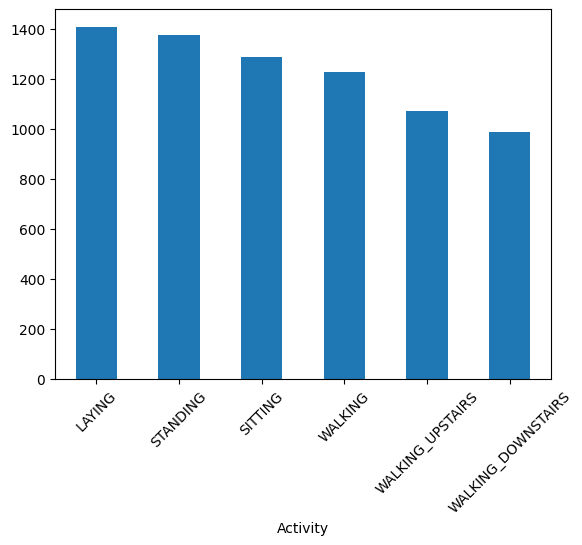

In [10]:
train['Activity'].value_counts().plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

In [11]:
X_train = train.drop(['Activity','subject'], axis=1)
y_train = train['Activity']

X_test = test.drop(['Activity','subject'], axis=1)
y_test = test['Activity']
print(X_train.shape)
print(y_train.shape)

(7352, 561)
(7352,)


PLOT-2
**FEATURE CORRELATION PLOT**

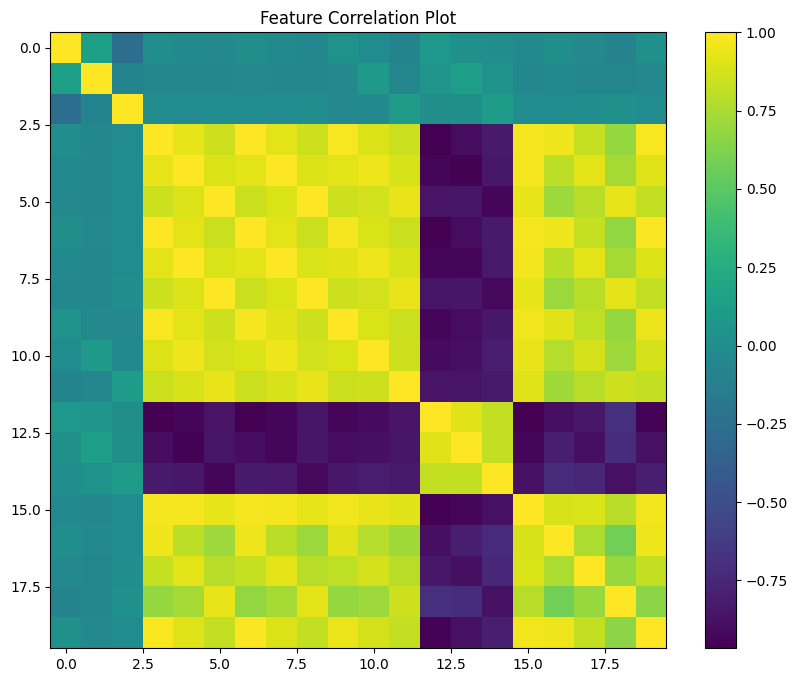

In [12]:
subset = X_train.iloc[:, :20]
corr = subset.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.title("Feature Correlation Plot")
plt.show()

PLOT-3
**BOXPLOTS GROUPED BY ACTIVITY**

<Axes: title={'center': 'tBodyAcc-mean()-X'}, xlabel='Activity'>

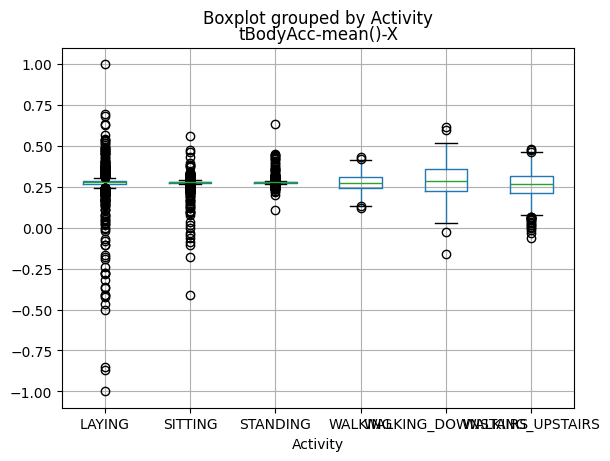

In [13]:
train.boxplot(column='tBodyAcc-mean()-X', by='Activity')

<Axes: title={'center': 'tBodyAcc-mean()-Y'}, xlabel='Activity'>

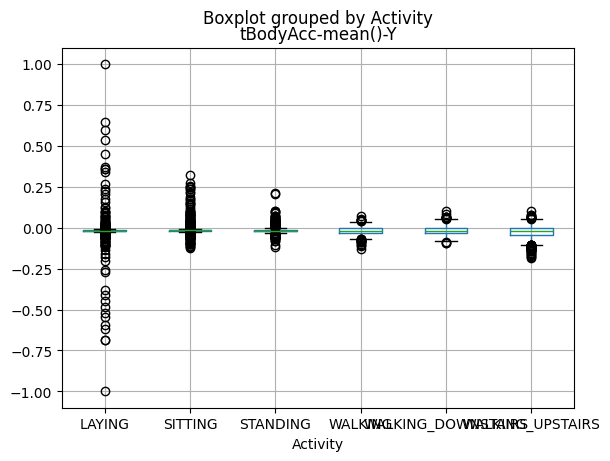

In [14]:
train.boxplot(column='tBodyAcc-mean()-Y', by='Activity')

<Axes: title={'center': 'tBodyAcc-mean()-Z'}, xlabel='Activity'>

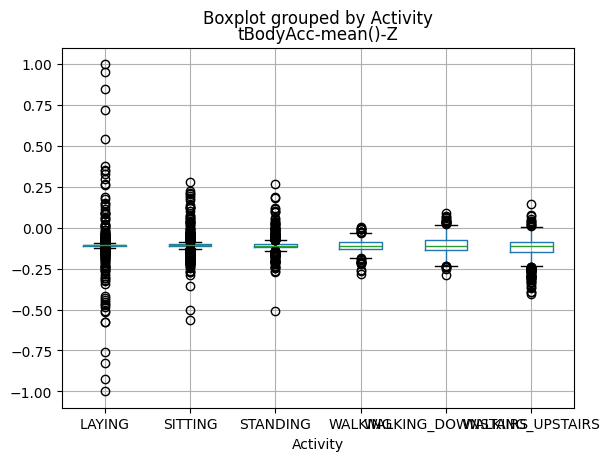

In [15]:
train.boxplot(column='tBodyAcc-mean()-Z', by='Activity')

PLOT-4

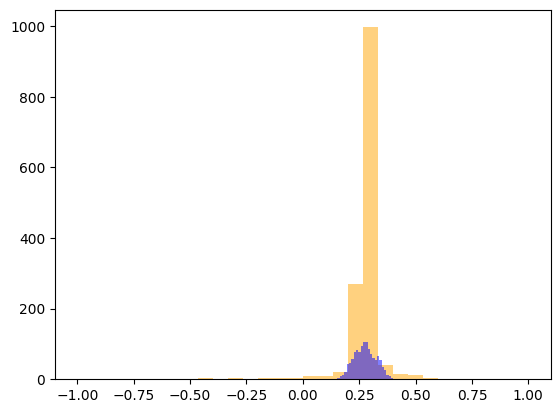

In [16]:
walking = train[train['Activity']=='WALKING']
laying = train[train['Activity']=='LAYING']


plt.hist(laying['tBodyAcc-mean()-X'], bins=30,alpha=0.5,color='orange')
plt.hist(walking['tBodyAcc-mean()-X'], bins=30,alpha=0.5,color='blue')

plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from sklearn.model_selection import train_test_split
train_X,val_X,train_y,val_y=train_test_split(X_train,y_train,random_state=1)

In [39]:
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score



def get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = DecisionTreeClassifier(max_leaf_nodes=max_leaf_nodes, random_state=1)
    model.fit(train_X, train_y)
    preds_val = model.predict(val_X)
    score=accuracy_score(val_y, preds_val)
    return(score)
for max_leaf_nodes in [5, 50, 500, 5000]:
    my_mae = get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y)
    print(f"Max leaf nodes: {max_leaf_nodes} \t\t Accuracy Score: {my_mae:.2f}")

Max leaf nodes: 5 		 Accuracy Score: 0.78
Max leaf nodes: 50 		 Accuracy Score: 0.93
Max leaf nodes: 500 		 Accuracy Score: 0.94
Max leaf nodes: 5000 		 Accuracy Score: 0.94


In [40]:
SVM_model=DecisionTreeRegressor(max_leaf_nodes=500,random_state=0)
SVM_model.fit(train_X,train_y)
predictions=SVM_model.predict(val_X)
score1=accuracy_score(val_y, predictions)
print(score1)

0.9347116430903155


In [42]:
SVM_model.fit(X_train,y_train)
test_predictions=SVM_model.predict(X_test)
score2=accuracy_score(y_test, test_predictions)
print(score2)

0.8547675602307431
